# Proyecto 4 - Predicción del consumo energético de un edificio

## Corte 1 - EDA y diagnóstico del dataset

**Asignatura:** Profundización III - Inteligencia Artificial  
**Dataset:** UCI Appliances Energy Prediction  
**Tarea:** Regresión temporal  
**Variable objetivo:** `Appliances` (Wh)

### Objetivo del notebook

Realizar la carga, diagnóstico y análisis exploratorio del dataset, estudiando su estructura temporal, calidad de datos, distribución del consumo energético, variables ambientales y posibles riesgos de fuga de información.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [ ]:
df = pd.read_csv("/content/energydata_complete.csv")

df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.200000,41.626667,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.200000,41.560000,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.200000,41.433333,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,6.433333,83.423333,17.133333,41.290000,18.1,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,6.366667,84.893333,17.200000,41.230000,18.1,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [ ]:
print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])

Número de filas: 19735
Número de columnas: 29


### Interpretación

El dataset contiene 19.735 observaciones y 29 columnas en el archivo CSV. La fuente UCI reporta 28 variables del conjunto de datos; adicionalmente, el archivo incluye la columna temporal `date`, utilizada para identificar el momento de cada medición.

In [ ]:
df.columns.tolist()

['date',
 'Appliances',
 'lights',
 'T1',
 'RH_1',
 'T2',
 'RH_2',
 'T3',
 'RH_3',
 'T4',
 'RH_4',
 'T5',
 'RH_5',
 'T6',
 'RH_6',
 'T7',
 'RH_7',
 'T8',
 'RH_8',
 'T9',
 'RH_9',
 'T_out',
 'Press_mm_hg',
 'RH_out',
 'Windspeed',
 'Visibility',
 'Tdewpoint',
 'rv1',
 'rv2']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9  

In [ ]:
df["date"] = pd.to_datetime(df["date"])

df["date"].dtype

dtype('<M8[ns]')

In [ ]:
print("Fecha inicial:", df["date"].min())
print("Fecha final:", df["date"].max())
print("Duración aproximada:", df["date"].max() - df["date"].min())

Fecha inicial: 2016-01-11 17:00:00
Fecha final: 2016-05-27 18:00:00
Duración aproximada: 137 days 01:00:00


In [ ]:
missing = df.isnull().sum()

missing[missing > 0]

,0


In [ ]:
print("Total de valores faltantes:", df.isnull().sum().sum())

Total de valores faltantes: 0


### Valores faltantes

No se encontraron valores faltantes en el dataset. Este resultado coincide con la documentación proporcionada por UCI. Aun así, la comprobación se realizó directamente sobre el archivo utilizado en el proyecto.

In [ ]:
duplicados = df.duplicated().sum()

print("Filas duplicadas:", duplicados)

Filas duplicadas: 0


### Registros duplicados

No se identificaron filas completamente duplicadas en el conjunto de datos.

In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,19735,2016-03-20 05:30:00,2016-01-11 17:00:00,2016-02-14 23:15:00,2016-03-20 05:30:00,2016-04-23 11:45:00,2016-05-27 18:00:00,NaN
Appliances,19735.0,97.694958,10.0,50.0,60.0,100.0,1080.0,102.524891
lights,19735.0,3.801875,0.0,0.0,0.0,0.0,70.0,7.935988
T1,19735.0,21.686571,16.79,20.76,21.6,22.6,26.26,1.606066
RH_1,19735.0,40.259739,27.023333,37.333333,39.656667,43.066667,63.36,3.979299
T2,19735.0,20.341219,16.1,18.79,20.0,21.5,29.856667,2.192974
RH_2,19735.0,40.42042,20.463333,37.9,40.5,43.26,56.026667,4.069813
T3,19735.0,22.267611,17.2,20.79,22.1,23.29,29.236,2.006111
RH_3,19735.0,39.2425,28.766667,36.9,38.53,41.76,50.163333,3.254576
T4,19735.0,20.855335,15.1,19.53,20.666667,22.1,26.2,2.042884


In [ ]:
df["Appliances"].describe()

,Appliances
count,19735.000000
mean,97.694958
std,102.524891
min,10.000000
25%,50.000000
50%,60.000000
75%,100.000000
max,1080.000000


In [ ]:
print("Media:", df["Appliances"].mean())
print("Mediana:", df["Appliances"].median())
print("Mínimo:", df["Appliances"].min())
print("Máximo:", df["Appliances"].max())

Media: 97.6949581960983
Mediana: 60.0
Mínimo: 10
Máximo: 1080


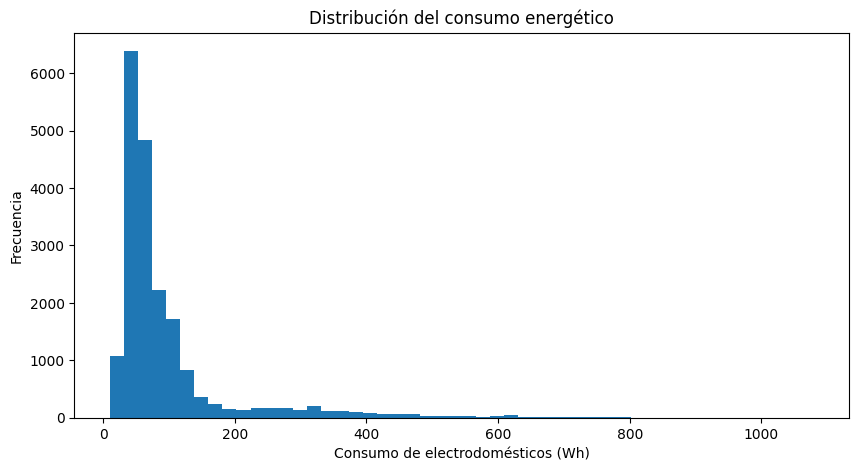

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(df["Appliances"], bins=50)

plt.xlabel("Consumo de electrodomésticos (Wh)")
plt.ylabel("Frecuencia")
plt.title("Distribución del consumo energético")

plt.show()

### Distribución del consumo

La variable objetivo `Appliances` presenta una distribución asimétrica hacia la derecha. La mayoría de las observaciones corresponden a niveles relativamente bajos de consumo, mientras que existen episodios de consumo considerablemente más alto.

Esta característica es relevante porque una métrica global puede ocultar un desempeño deficiente durante los picos de consumo. Por esta razón, posteriormente se analizará el error de predicción por separado para periodos de consumo bajo y alto.

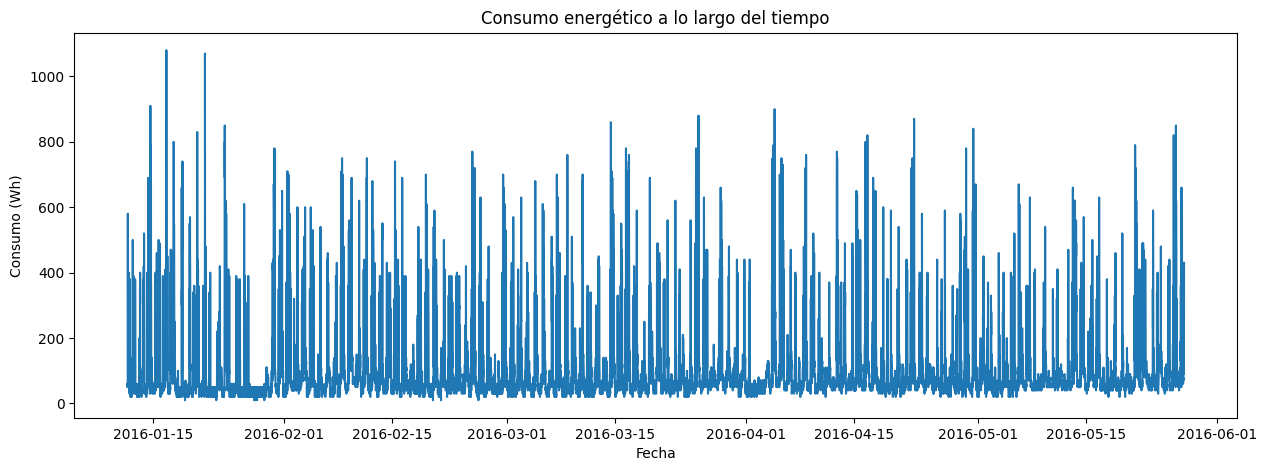

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(df["date"], df["Appliances"])

plt.xlabel("Fecha")
plt.ylabel("Consumo (Wh)")
plt.title("Consumo energético a lo largo del tiempo")

plt.show()

### Evolución temporal del consumo

El consumo energético presenta una alta variabilidad a lo largo del periodo de observación, con numerosos episodios de bajo consumo y picos puntuales de mayor demanda.

Debido a la naturaleza temporal de los datos, una separación aleatoria entre entrenamiento y prueba podría mezclar observaciones cercanas en el tiempo y producir una evaluación demasiado optimista. Por ello, el proyecto utilizará una partición cronológica.

In [ ]:
# Características temporales para el análisis exploratorio

df["hour"] = df["date"].dt.hour
df["day_of_week"] = df["date"].dt.dayofweek
df["day_name"] = df["date"].dt.day_name()
df["month"] = df["date"].dt.month
df["weekend"] = (df["day_of_week"] >= 5).astype(int)

df[["date", "hour", "day_of_week", "day_name", "month", "weekend"]].head()

,date,hour,day_of_week,day_name,month,weekend
0,2016-01-11 17:00:00,17,0,Monday,1,0
1,2016-01-11 17:10:00,17,0,Monday,1,0
2,2016-01-11 17:20:00,17,0,Monday,1,0
3,2016-01-11 17:30:00,17,0,Monday,1,0
4,2016-01-11 17:40:00,17,0,Monday,1,0


### Características temporales

A partir de la columna `date` se extrajeron variables como hora del día, día de la semana, mes y fin de semana. Estas características permiten estudiar patrones temporales del consumo sin utilizar información futura.

In [ ]:
consumo_hora = df.groupby("hour")["Appliances"].agg(
    ["mean", "median", "std", "count"]
)

consumo_hora

,mean,median,std,count
hour,,,,
0,52.785888,50.0,25.615928,822
1,51.326034,50.0,19.288647,822
2,49.075426,50.0,10.694366,822
3,48.236010,50.0,11.445056,822
4,49.355231,50.0,10.244173,822
5,52.737226,50.0,27.301297,822
6,57.712895,50.0,46.446179,822
7,78.649635,60.0,81.476935,822
8,106.143552,60.0,112.102458,822


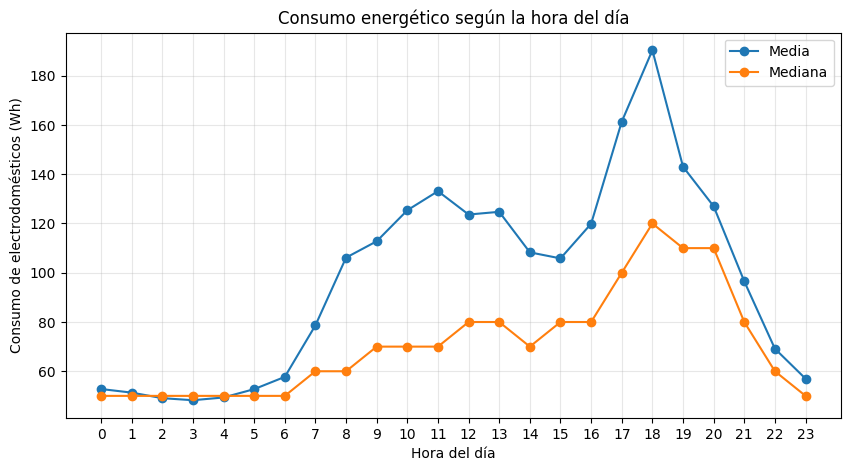

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    consumo_hora.index,
    consumo_hora["mean"],
    marker="o",
    label="Media"
)

plt.plot(
    consumo_hora.index,
    consumo_hora["median"],
    marker="o",
    label="Mediana"
)

plt.xlabel("Hora del día")
plt.ylabel("Consumo de electrodomésticos (Wh)")
plt.title("Consumo energético según la hora del día")
plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Interpretación del patrón horario

El consumo energético presenta un patrón horario claramente diferenciado. Durante la madrugada, aproximadamente entre las 00:00 y las 06:00, los niveles de consumo son relativamente bajos y estables. A partir de las primeras horas de la mañana el consumo comienza a incrementarse.

El mayor consumo promedio se observa alrededor de las 18:00, seguido por una reducción progresiva durante la noche. Además, durante las horas de mayor consumo existe una diferencia considerable entre la media y la mediana, lo que sugiere la presencia de episodios puntuales de consumo elevado.

Estos resultados indican que la hora del día puede contener información predictiva relevante. Sin embargo, el patrón observado representa una asociación temporal y no permite establecer relaciones causales.

In [ ]:
orden_dias = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

consumo_dia = (
    df.groupby("day_name")["Appliances"]
    .agg(["mean", "median"])
    .reindex(orden_dias)
)

consumo_dia

,mean,median
day_name,,
Monday,111.450684,60.0
Tuesday,87.125000,60.0
Wednesday,89.930556,70.0
Thursday,90.434028,60.0
Friday,104.622144,60.0
Saturday,106.246345,70.0
Sunday,94.915936,60.0


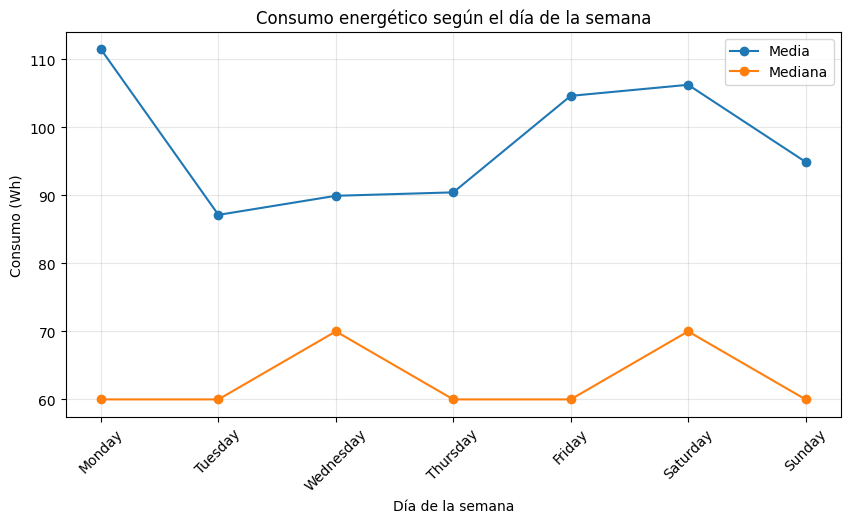

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    consumo_dia.index,
    consumo_dia["mean"],
    marker="o",
    label="Media"
)

plt.plot(
    consumo_dia.index,
    consumo_dia["median"],
    marker="o",
    label="Mediana"
)

plt.xlabel("Día de la semana")
plt.ylabel("Consumo (Wh)")
plt.title("Consumo energético según el día de la semana")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Interpretación del patrón semanal

Se observan diferencias en el consumo promedio entre los días de la semana. El lunes presenta el promedio más elevado, mientras que el martes registra uno de los menores valores medios.

Sin embargo, las medianas son considerablemente más estables y se encuentran aproximadamente entre 60 y 70 Wh. La diferencia entre media y mediana vuelve a evidenciar que episodios de consumo elevado influyen de manera importante sobre los promedios.

En comparación con el patrón horario, las diferencias entre días parecen menos pronunciadas, por lo que la hora del día muestra inicialmente una asociación más clara con el comportamiento del consumo.

In [ ]:
df.groupby("weekend")["Appliances"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
weekend,,,,
0,14263,96.587674,60.0,103.086372
1,5472,100.581140,70.0,100.998987


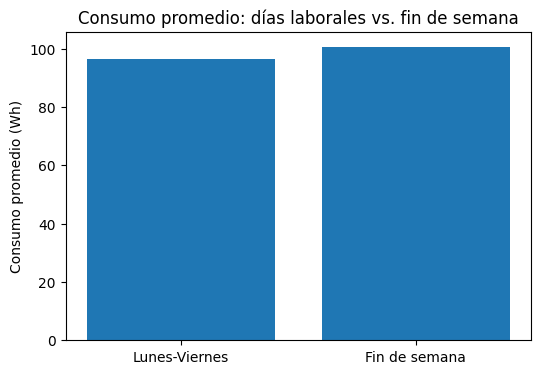

In [ ]:
consumo_weekend = df.groupby("weekend")["Appliances"].mean()

plt.figure(figsize=(6, 4))

plt.bar(
    ["Lunes-Viernes", "Fin de semana"],
    consumo_weekend.values
)

plt.ylabel("Consumo promedio (Wh)")
plt.title("Consumo promedio: días laborales vs. fin de semana")

plt.show()

### Días laborales y fines de semana

El consumo promedio durante los fines de semana es ligeramente superior al observado entre lunes y viernes. Sin embargo, la diferencia es pequeña.

Por esta razón, el análisis exploratorio no proporciona evidencia suficiente para afirmar que pertenecer a un fin de semana determine por sí solo un cambio importante en el consumo. La variable podrá conservarse inicialmente como característica temporal y su utilidad predictiva deberá evaluarse posteriormente mediante validación.

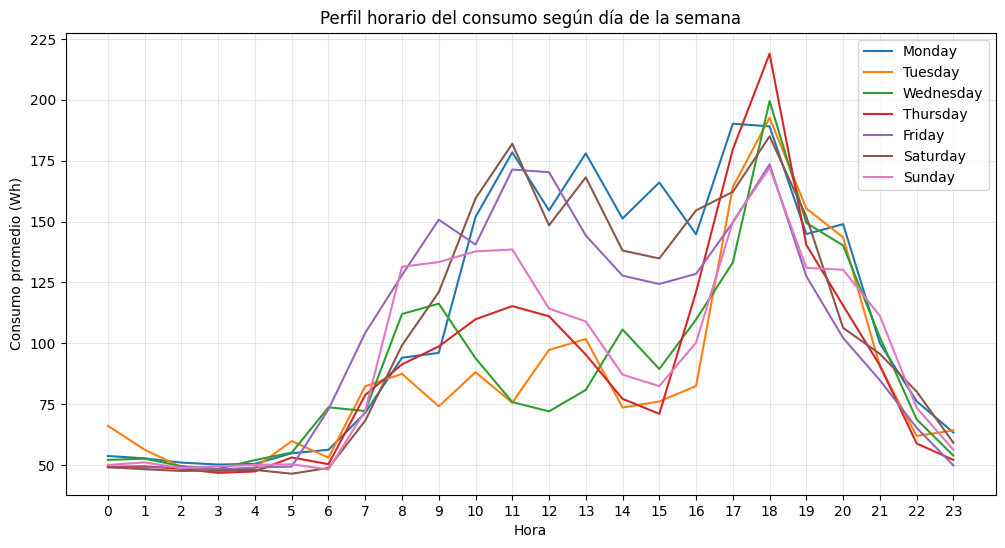

In [ ]:
perfil_horario_dia = (
    df.groupby(["day_name", "hour"])["Appliances"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

for dia in orden_dias:
    datos_dia = perfil_horario_dia[
        perfil_horario_dia["day_name"] == dia
    ]

    plt.plot(
        datos_dia["hour"],
        datos_dia["Appliances"],
        label=dia
    )

plt.xlabel("Hora")
plt.ylabel("Consumo promedio (Wh)")
plt.title("Perfil horario del consumo según día de la semana")
plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Días laborales y fines de semana

El consumo promedio durante los fines de semana es ligeramente superior al observado entre lunes y viernes. Sin embargo, la diferencia es pequeña.

Por esta razón, el análisis exploratorio no proporciona evidencia suficiente para afirmar que pertenecer a un fin de semana determine por sí solo un cambio importante en el consumo. La variable podrá conservarse inicialmente como característica temporal y su utilidad predictiva deberá evaluarse posteriormente mediante validación.

In [ ]:
temperature_cols = [
    col for col in df.columns
    if col.startswith("T") and col[1:].isdigit()
]

humidity_cols = [
    col for col in df.columns
    if col.startswith("RH_")
]

print("Temperaturas interiores:")
print(temperature_cols)

print("\nHumedades:")
print(humidity_cols)

Temperaturas interiores:
['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9']

Humedades:
['RH_1', 'RH_2', 'RH_3', 'RH_4', 'RH_5', 'RH_6', 'RH_7', 'RH_8', 'RH_9', 'RH_out']


In [ ]:
df[temperature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
T1,19735.0,21.686571,1.606066,16.790000,20.760000,21.600000,22.600000,26.260000
T2,19735.0,20.341219,2.192974,16.100000,18.790000,20.000000,21.500000,29.856667
T3,19735.0,22.267611,2.006111,17.200000,20.790000,22.100000,23.290000,29.236000
T4,19735.0,20.855335,2.042884,15.100000,19.530000,20.666667,22.100000,26.200000
T5,19735.0,19.592106,1.844623,15.330000,18.277500,19.390000,20.619643,25.795000
T6,19735.0,7.910939,6.090347,-6.065000,3.626667,7.300000,11.256000,28.290000
T7,19735.0,20.267106,2.109993,15.390000,18.700000,20.033333,21.600000,26.000000
T8,19735.0,22.029107,1.956162,16.306667,20.790000,22.100000,23.390000,27.230000
T9,19735.0,19.485828,2.014712,14.890000,18.000000,19.390000,20.600000,24.500000


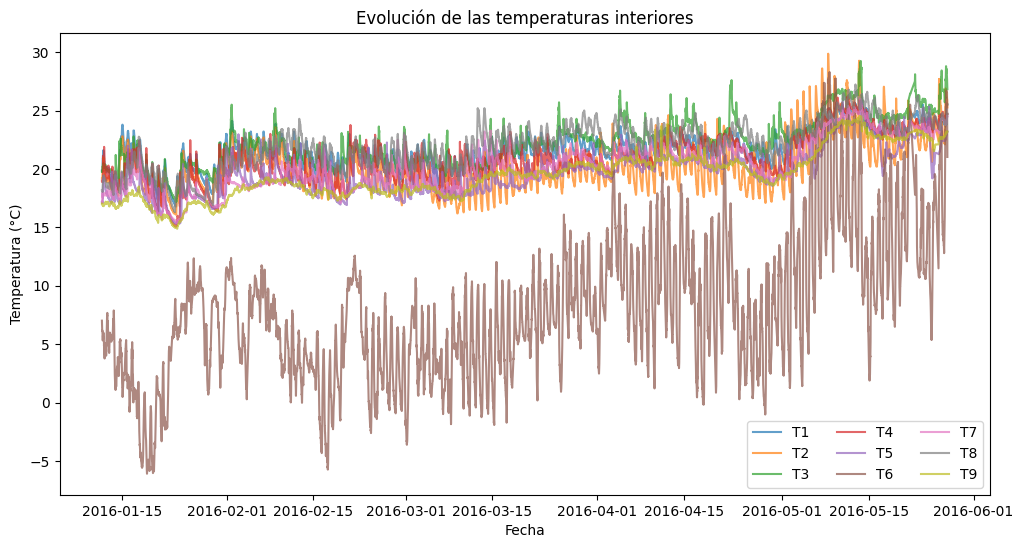

In [ ]:
plt.figure(figsize=(12, 6))

for col in temperature_cols:
    plt.plot(
        df["date"],
        df[col],
        label=col,
        alpha=0.7
    )

plt.xlabel("Fecha")
plt.ylabel("Temperatura (°C)")
plt.title("Evolución de las temperaturas interiores")
plt.legend(ncol=3)
plt.show()

In [ ]:
df[humidity_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
RH_1,19735.0,40.259739,3.979299,27.023333,37.333333,39.656667,43.066667,63.360000
RH_2,19735.0,40.420420,4.069813,20.463333,37.900000,40.500000,43.260000,56.026667
RH_3,19735.0,39.242500,3.254576,28.766667,36.900000,38.530000,41.760000,50.163333
RH_4,19735.0,39.026904,4.341321,27.660000,35.530000,38.400000,42.156667,51.090000
RH_5,19735.0,50.949283,9.022034,29.815000,45.400000,49.090000,53.663333,96.321667
RH_6,19735.0,54.609083,31.149806,1.000000,30.025000,55.290000,83.226667,99.900000
RH_7,19735.0,35.388200,5.114208,23.200000,31.500000,34.863333,39.000000,51.400000
RH_8,19735.0,42.936165,5.224361,29.600000,39.066667,42.375000,46.536000,58.780000
RH_9,19735.0,41.552401,4.151497,29.166667,38.500000,40.900000,44.338095,53.326667
RH_out,19735.0,79.750418,14.901088,24.000000,70.333333,83.666667,91.666667,100.000000


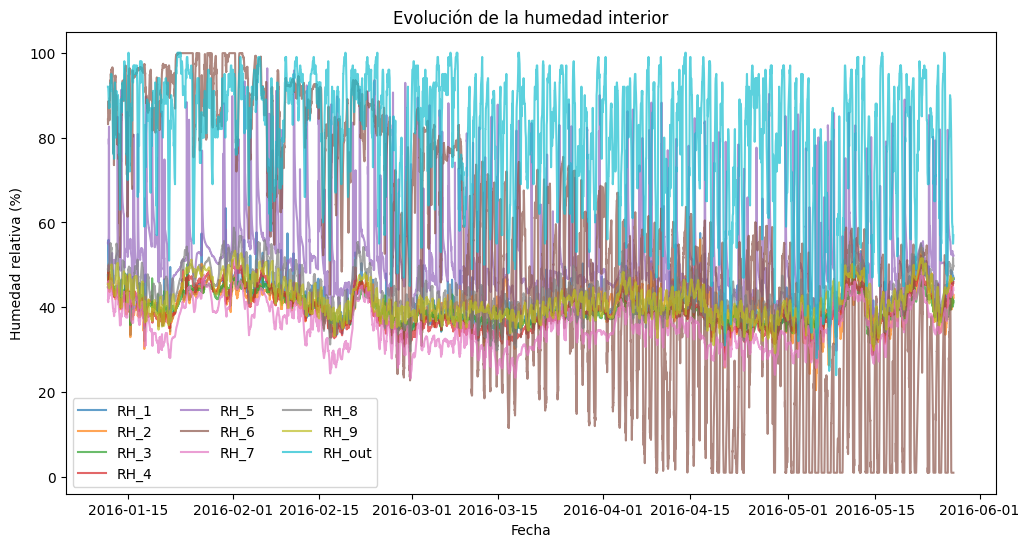

In [ ]:
plt.figure(figsize=(12, 6))

for col in humidity_cols:
    plt.plot(
        df["date"],
        df[col],
        label=col,
        alpha=0.7
    )

plt.xlabel("Fecha")
plt.ylabel("Humedad relativa (%)")
plt.title("Evolución de la humedad interior")
plt.legend(ncol=3)
plt.show()

In [ ]:
weather_cols = [
    "T_out",
    "Press_mm_hg",
    "RH_out",
    "Windspeed",
    "Visibility",
    "Tdewpoint"
]

df[weather_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
T_out,19735.0,7.411665,5.317409,-5.0,3.666667,6.916667,10.408333,26.1
Press_mm_hg,19735.0,755.522602,7.399441,729.3,750.933333,756.100000,760.933333,772.3
RH_out,19735.0,79.750418,14.901088,24.0,70.333333,83.666667,91.666667,100.0
Windspeed,19735.0,4.039752,2.451221,0.0,2.000000,3.666667,5.500000,14.0
Visibility,19735.0,38.330834,11.794719,1.0,29.000000,40.000000,40.000000,66.0
Tdewpoint,19735.0,3.760707,4.194648,-6.6,0.900000,3.433333,6.566667,15.5


In [ ]:
weather_corr = (
    df[weather_cols + ["Appliances"]]
    .corr()["Appliances"]
    .drop("Appliances")
    .sort_values(ascending=False)
)

weather_corr

,Appliances
T_out,0.099155
Windspeed,0.087122
Tdewpoint,0.015353
Visibility,0.000230
Press_mm_hg,-0.034885
RH_out,-0.152282


In [ ]:
numeric_df = df.select_dtypes(include=np.number)

correlations = (
    numeric_df
    .corr()["Appliances"]
    .drop("Appliances")
    .sort_values(key=abs, ascending=False)
)

correlations

,Appliances
hour,0.216792
lights,0.197278
RH_out,-0.152282
T2,0.120073
T6,0.117638
T_out,0.099155
RH_8,-0.094039
Windspeed,0.087122
RH_1,0.086031
T3,0.085060


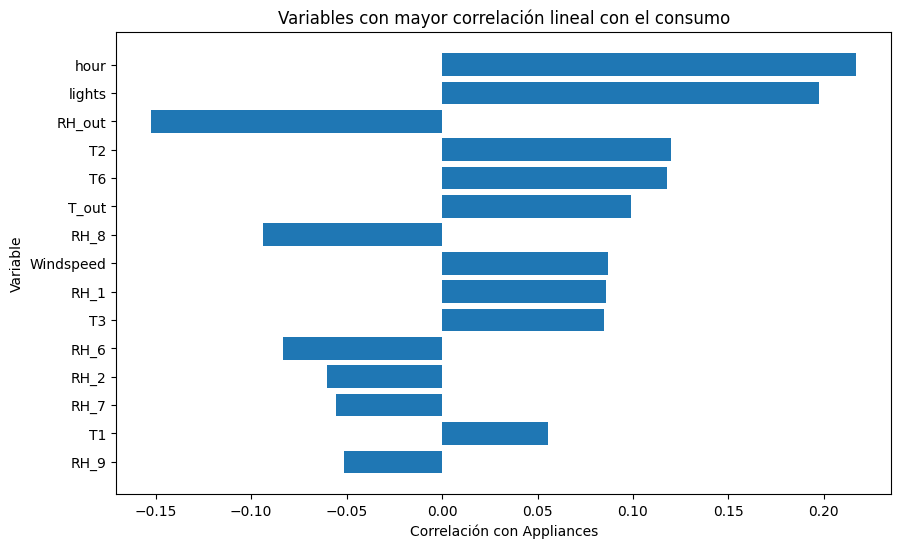

In [ ]:
top_corr = correlations.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_corr.index[::-1],
    top_corr.values[::-1]
)

plt.xlabel("Correlación con Appliances")
plt.ylabel("Variable")
plt.title("Variables con mayor correlación lineal con el consumo")

plt.show()

### Correlaciones con la variable objetivo

Las correlaciones lineales individuales con `Appliances` son relativamente bajas. Entre las asociaciones más destacadas aparecen la hora del día (`hour`), el consumo de iluminación (`lights`), algunas temperaturas y variables de humedad.

La ausencia de correlaciones lineales muy elevadas indica que ninguna de estas variables, considerada individualmente, explica de forma simple el comportamiento completo del consumo.

Además, una correlación baja no implica necesariamente ausencia de capacidad predictiva, ya que pueden existir relaciones no lineales e interacciones entre variables. Por ejemplo, el análisis horario muestra un patrón evidente que no corresponde a una relación lineal simple.

Finalmente, estas asociaciones no deben interpretarse como relaciones causales.

In [ ]:
df[["rv1", "rv2"]].describe()

,rv1,rv2
count,19735.000000,19735.000000
mean,24.988033,24.988033
std,14.496634,14.496634
min,0.005322,0.005322
25%,12.497889,12.497889
50%,24.897653,24.897653
75%,37.583769,37.583769
max,49.996530,49.996530


In [ ]:
print(
    "Correlación rv1 vs rv2:",
    df["rv1"].corr(df["rv2"])
)

print(
    "Correlación rv1 vs Appliances:",
    df["rv1"].corr(df["Appliances"])
)

print(
    "Correlación rv2 vs Appliances:",
    df["rv2"].corr(df["Appliances"])
)

Correlación rv1 vs rv2: 0.9999999999999999
Correlación rv1 vs Appliances: -0.011144917533634453
Correlación rv2 vs Appliances: -0.011144917533634453


In [ ]:
print(
    "¿rv1 y rv2 son exactamente iguales?:",
    (df["rv1"] == df["rv2"]).all()
)

¿rv1 y rv2 son exactamente iguales?: True


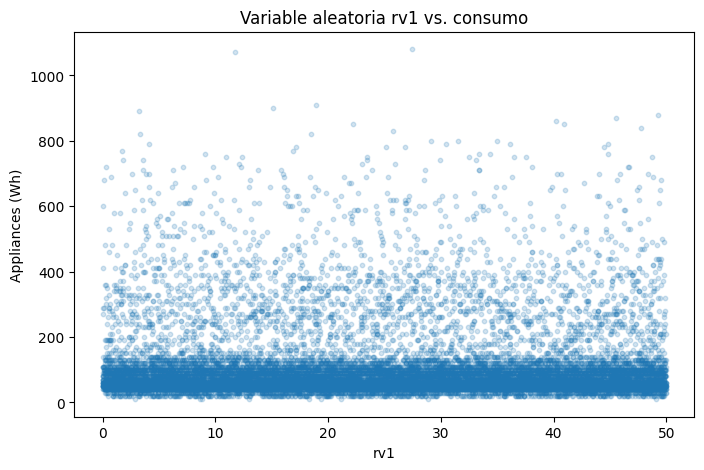

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["rv1"],
    df["Appliances"],
    alpha=0.2,
    s=10
)

plt.xlabel("rv1")
plt.ylabel("Appliances (Wh)")
plt.title("Variable aleatoria rv1 vs. consumo")

plt.show()

### Análisis de las variables aleatorias `rv1` y `rv2`

La auditoría mostró que `rv1` y `rv2` contienen exactamente los mismos valores en todas las observaciones del dataset. Por tanto, existe redundancia completa entre ambas variables.

Además, la inspección gráfica de `rv1` frente a `Appliances` no muestra un patrón evidente de asociación con el consumo. De acuerdo con la documentación del dataset, estas variables fueron incorporadas como variables aleatorias para permitir evaluar la relevancia de características.

Por esta razón, `rv1` y `rv2` serán tratadas con especial precaución. Su inclusión en modelos posteriores deberá justificarse mediante evidencia predictiva y no simplemente por estar disponibles en el dataset.

In [ ]:
p90 = df["Appliances"].quantile(0.90)

print("Percentil 90 del consumo:", p90)

Percentil 90 del consumo: 196.00000000002183


In [ ]:
df["high_consumption"] = (
    df["Appliances"] >= p90
).astype(int)

df["high_consumption"].value_counts()

,count
high_consumption,
0,17761
1,1974


In [ ]:
df["high_consumption"].value_counts(normalize=True) * 100

,proportion
high_consumption,
0,89.997466
1,10.002534


### Identificación exploratoria de periodos de alto consumo

Para facilitar el análisis posterior de errores, se definió inicialmente como consumo alto aquel igual o superior al percentil 90 de `Appliances`.

Esta variable no se utilizará como objetivo de clasificación. El problema continúa siendo de regresión. Su propósito es permitir comparar posteriormente el comportamiento de los residuos entre periodos de consumo habitual y periodos de consumo elevado.

In [ ]:
df.nlargest(
    10,
    "Appliances"
)[
    [
        "date",
        "Appliances",
        "hour",
        "day_name",
        "T_out",
        "RH_out"
    ]
]

,date,Appliances,hour,day_name,T_out,RH_out
731,2016-01-16 18:50:00,1080,18,Saturday,2.083333,85.500000
1451,2016-01-21 18:50:00,1070,18,Thursday,-0.616667,82.833333
432,2016-01-14 17:00:00,910,17,Thursday,4.600000,76.000000
12088,2016-04-04 15:40:00,900,15,Monday,14.766667,59.666667
1452,2016-01-21 19:00:00,890,19,Thursday,-0.800000,84.000000
10668,2016-03-25 19:00:00,880,19,Friday,8.100000,74.000000
14693,2016-04-22 17:50:00,870,17,Friday,13.033333,57.000000
9031,2016-03-14 10:10:00,860,10,Monday,2.400000,80.000000
1821,2016-01-24 08:30:00,850,8,Sunday,6.350000,95.500000
19582,2016-05-26 16:40:00,850,16,Thursday,20.866667,46.000000


# Conclusiones del análisis exploratorio

El análisis realizado permite establecer los siguientes hallazgos iniciales:

1. El dataset contiene **19.735 observaciones** correspondientes a mediciones realizadas aproximadamente cada 10 minutos entre enero y mayo de 2016.

2. No se identificaron valores faltantes ni filas completamente duplicadas en el archivo analizado.

3. La variable objetivo `Appliances` presenta una distribución asimétrica hacia la derecha. La mayoría de las observaciones corresponden a consumos relativamente bajos, mientras que existen episodios puntuales de consumo considerablemente elevado.

4. Se identificó un patrón temporal diario. El consumo permanece relativamente bajo durante la madrugada, aumenta durante el día y alcanza sus mayores niveles promedio durante las últimas horas de la tarde, especialmente alrededor de las 18:00.

5. También existen diferencias entre días de la semana, aunque parecen menos pronunciadas que las diferencias observadas entre horas del día.

6. El consumo promedio durante los fines de semana es ligeramente superior al de los días laborales, pero la diferencia observada es pequeña.

7. Las correlaciones lineales individuales entre las variables disponibles y `Appliances` son generalmente moderadas o bajas. Esto sugiere que el comportamiento del consumo no puede explicarse mediante una única relación lineal simple y que pueden existir relaciones no lineales e interacciones entre variables.

8. La variable `hour` presenta una de las asociaciones lineales más destacadas con el consumo y el análisis gráfico confirma la existencia de un patrón horario. Sin embargo, dicho patrón no es estrictamente lineal.

9. Las variables aleatorias `rv1` y `rv2` son exactamente iguales entre sí en el archivo analizado y no muestran visualmente una relación clara con el consumo. Su utilidad predictiva deberá evaluarse posteriormente.

10. El percentil 90 de `Appliances` se encuentra aproximadamente en **196 Wh**. Este valor se utilizará como criterio exploratorio para distinguir periodos de consumo elevado durante el posterior análisis de residuos.

11. Debido a la estructura temporal del dataset, la evaluación de los modelos deberá realizarse mediante una separación cronológica. Una división aleatoria podría mezclar observaciones temporalmente cercanas entre entrenamiento, validación y prueba y producir una estimación demasiado optimista del desempeño.

Estos resultados corresponden a asociaciones observadas dentro del dataset y no deben interpretarse como evidencia de relaciones causales ni como demostración de ahorro energético.

In [ ]:
df = df.sort_values("date").reset_index(drop=True)

print("Primera fecha:", df["date"].min())
print("Última fecha:", df["date"].max())

print(
    "¿Las fechas están ordenadas?:",
    df["date"].is_monotonic_increasing
)

Primera fecha: 2016-01-11 17:00:00
Última fecha: 2016-05-27 18:00:00
¿Las fechas están ordenadas?: True


### Preparación para la partición temporal

Antes de realizar la separación de los datos, las observaciones fueron ordenadas cronológicamente mediante la variable `date`.

Esta decisión es necesaria porque el problema presenta una estructura temporal y la evaluación debe representar un escenario en el que el modelo aprende a partir del pasado y posteriormente realiza predicciones sobre periodos futuros.

In [ ]:
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = df.iloc[:train_end].copy()
validation = df.iloc[train_end:val_end].copy()
test = df.iloc[val_end:].copy()

print("Total:", len(df))
print("Train:", len(train))
print("Validation:", len(validation))
print("Test:", len(test))

Total: 19735
Train: 13814
Validation: 2960
Test: 2961


In [ ]:
print("TRAIN")
print("Inicio:", train["date"].min())
print("Fin:", train["date"].max())

print("\nVALIDATION")
print("Inicio:", validation["date"].min())
print("Fin:", validation["date"].max())

print("\nTEST")
print("Inicio:", test["date"].min())
print("Fin:", test["date"].max())

TRAIN
Inicio: 2016-01-11 17:00:00
Fin: 2016-04-16 15:10:00

VALIDATION
Inicio: 2016-04-16 15:20:00
Fin: 2016-05-07 04:30:00

TEST
Inicio: 2016-05-07 04:40:00
Fin: 2016-05-27 18:00:00


In [ ]:
print(
    "Train termina antes de Validation:",
    train["date"].max() < validation["date"].min()
)

print(
    "Validation termina antes de Test:",
    validation["date"].max() < test["date"].min()
)

Train termina antes de Validation: True
Validation termina antes de Test: True


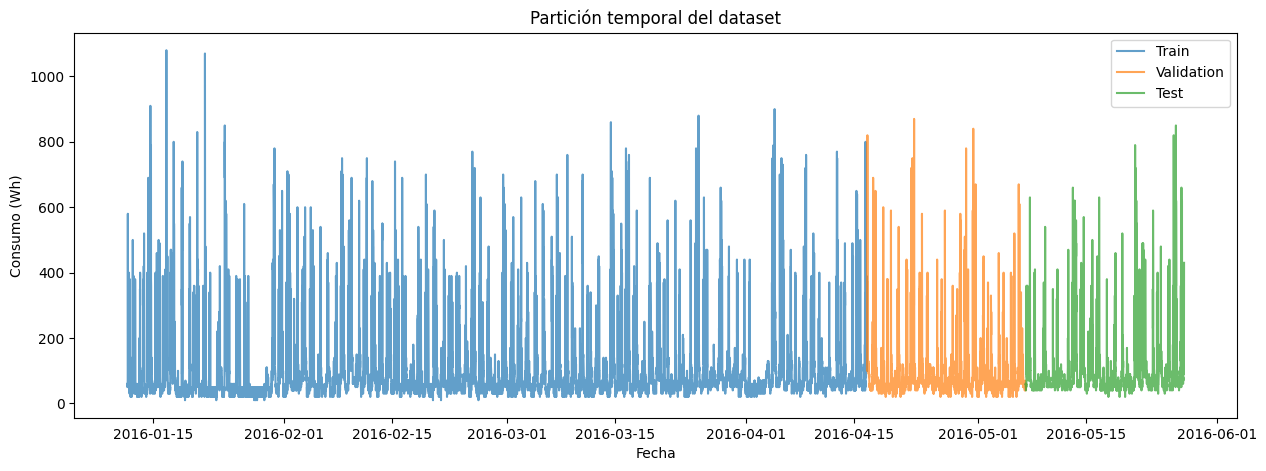

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(
    train["date"],
    train["Appliances"],
    label="Train",
    alpha=0.7
)

plt.plot(
    validation["date"],
    validation["Appliances"],
    label="Validation",
    alpha=0.7
)

plt.plot(
    test["date"],
    test["Appliances"],
    label="Test",
    alpha=0.7
)

plt.xlabel("Fecha")
plt.ylabel("Consumo (Wh)")
plt.title("Partición temporal del dataset")
plt.legend()

plt.show()

In [ ]:
print(
    f"Train: {len(train) / len(df) * 100:.2f}%"
)

print(
    f"Validation: {len(validation) / len(df) * 100:.2f}%"
)

print(
    f"Test: {len(test) / len(df) * 100:.2f}%"
)

Train: 70.00%
Validation: 15.00%
Test: 15.00%


## Protocolo de partición temporal

Debido a la naturaleza temporal del problema, se utilizó una separación cronológica en lugar de una partición aleatoria.

Las observaciones iniciales se asignaron al conjunto de entrenamiento (70%), el siguiente bloque temporal al conjunto de validación (15%) y el periodo final al conjunto de prueba (15%).

La estructura utilizada es:

**Pasado → Entrenamiento → Validación → Prueba → Futuro**

Esta estrategia busca representar de manera más realista el escenario de uso esperado: el modelo se entrena utilizando información histórica y posteriormente realiza predicciones sobre observaciones futuras.

Una partición aleatoria podría colocar observaciones temporalmente cercanas en entrenamiento y prueba, produciendo una estimación excesivamente optimista del desempeño.

El conjunto de prueba permanecerá reservado y no será utilizado para seleccionar características, modelos o hiperparámetros.

In [ ]:
comparacion_consumo = pd.DataFrame({
    "Train": train["Appliances"].describe(),
    "Validation": validation["Appliances"].describe(),
    "Test": test["Appliances"].describe()
})

comparacion_consumo

,Train,Validation,Test
count,13814.000000,2960.000000,2961.000000
mean,98.775156,93.422297,96.926714
std,106.857292,92.254684,90.888693
min,10.000000,20.000000,20.000000
25%,50.000000,50.000000,50.000000
50%,60.000000,60.000000,60.000000
75%,100.000000,100.000000,100.000000
max,1080.000000,870.000000,850.000000


### Comparación de la variable objetivo entre particiones

La distribución de `Appliances` presenta características relativamente similares entre los tres bloques temporales. La mediana es de 60 Wh y el tercer cuartil de 100 Wh tanto en entrenamiento como en validación y prueba.

Las medias presentan algunas diferencias: aproximadamente 98,78 Wh en entrenamiento, 93,42 Wh en validación y 96,93 Wh en prueba. También se observa una mayor dispersión en el conjunto de entrenamiento.

Los valores máximos varían entre periodos: 1080 Wh en entrenamiento, 870 Wh en validación y 850 Wh en prueba. Esto evidencia que los episodios extremos de consumo no se distribuyen de manera idéntica a lo largo del tiempo.

Estas diferencias no justifican mezclar aleatoriamente los datos, ya que forman parte de la variabilidad temporal que el protocolo de evaluación busca conservar.

In [ ]:
for nombre, datos in [
    ("Train", train),
    ("Validation", validation),
    ("Test", test)
]:
    porcentaje_alto = (
        (datos["Appliances"] >= p90).mean() * 100
    )

    print(
        f"{nombre}: {porcentaje_alto:.2f}% de consumo alto"
    )

Train: 10.71% de consumo alto
Validation: 8.04% de consumo alto
Test: 8.65% de consumo alto


### Conclusión del protocolo de partición

La separación cronológica produjo tres bloques consecutivos y sin solapamiento temporal:

- **Entrenamiento:** 11 de enero de 2016 17:00 a 16 de abril de 2016 15:10.
- **Validación:** 16 de abril de 2016 15:20 a 7 de mayo de 2016 04:30.
- **Prueba:** 7 de mayo de 2016 04:40 a 27 de mayo de 2016 18:00.

Los tres subconjuntos mantienen valores centrales similares de la variable objetivo: la mediana es de 60 Wh y el tercer cuartil de 100 Wh en los tres periodos. Sin embargo, existen diferencias en la media, dispersión, valores máximos y frecuencia de episodios de alto consumo.

Utilizando 196 Wh como umbral exploratorio de consumo alto, estos episodios representan el 10,71% del entrenamiento, 8,04% de validación y 8,65% de prueba.

Estas diferencias se conservarán porque forman parte de la variabilidad temporal real del problema. No se realizará mezcla aleatoria entre los bloques.

A partir de este punto, el conjunto de prueba queda reservado y no será utilizado para seleccionar modelos, características o hiperparámetros.